In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from matplotlib.collections import LineCollection
from src.results_paper import *
from src.TimeSeriesAnalysis import *
from src.process_data import process_all_roots, summarize_all_dirs
from IPython.display import clear_output
plt.style.use('properties.mplstyle')

In [21]:
results_folder = "../results/TimeSeries/2D"
create_folder(results_folder)

## 1 COLOR - MULTIPLES $p_0$

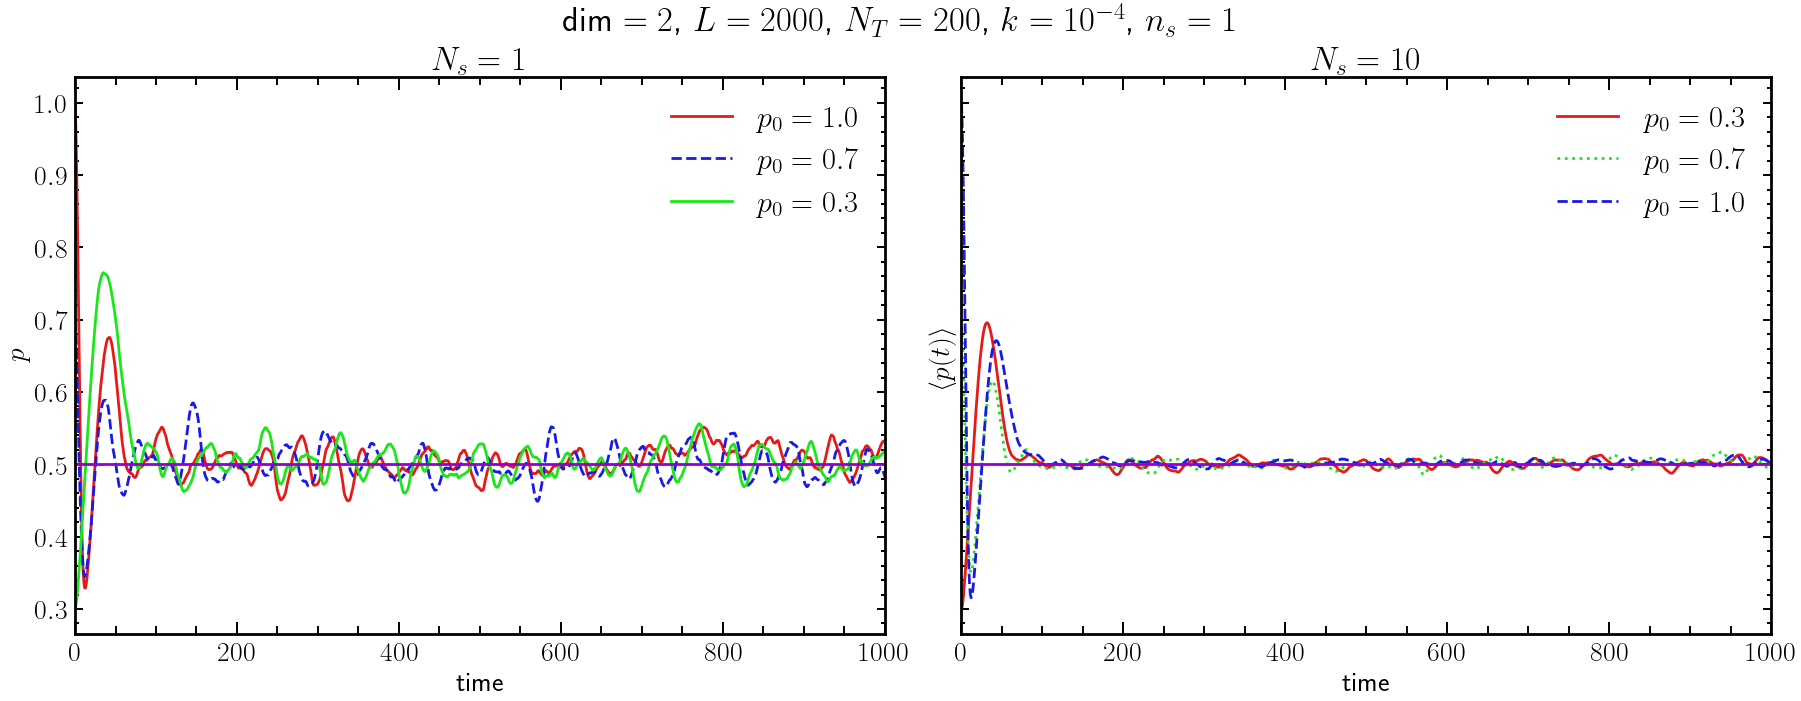

In [22]:
import matplotlib.pyplot as plt

# =========================
# PAINEL ESQUERDO: N_s = 1
# =========================
L = 2000
dim = 2
nc = 1
rho = 1 / nc
k = 1.0e-04
NT = 200
p0 = 1.0
seed = 1
z_level = 0

path_dir_raw = f"../SOP_data/raw/bond_percolation/num_colors_{nc}/dim_{dim}/L_{L}/NT_constant/NT_{NT}/k_{k:.1e}/rho_{rho:.4e}/data/"
fn1 = path_dir_raw + "complex_seed_22744820_ts_20260326T151418_P0_0.10_p0_1.00.json"
fn2 = path_dir_raw + "complex_seed_431596886_ts_20260326T151800_P0_0.10_p0_0.70.json"
fn3 = path_dir_raw + "complex_seed_488465044_ts_20260326T151730_P0_0.10_p0_0.30.json"

dicT1 = read_experiment_json(fn1)
dicT2 = read_experiment_json(fn2)
dicT3 = read_experiment_json(fn3)

order_raw = 1
pc = 0.5
lw = 2.0

colors_used = [
    (0.9, 0.1, 0.1),
    (0.1, 0.1, 0.9),
    (0.1, 0.9, 0.1),
    (1.0, 0.5, 0.0),
    (0.8, 0.2, 0.8),
    (0.2, 0.8, 0.8),
    (1.0, 1.0, 0.0),
    (0.6, 0.4, 0.2),
]

pt1 = dicT1['results'][f'order_percolation {order_raw}']['data']['pt']
t1  = dicT1['results'][f'order_percolation {order_raw}']['data']['time']

pt2 = dicT2['results'][f'order_percolation {order_raw}']['data']['pt']
t2  = dicT2['results'][f'order_percolation {order_raw}']['data']['time']

pt3 = dicT3['results'][f'order_percolation {order_raw}']['data']['pt']
t3  = dicT3['results'][f'order_percolation {order_raw}']['data']['time']


# ==========================
# PAINEL DIREITO: N_s = 30
# ==========================
path_dir_pub = f"../SOP_data/published/bond_percolation/num_colors_{nc}/dim_{dim}/L_{L}/NT_constant/NT_{NT}/k_{k:.1e}/rho_{rho:.4e}/"
bundle_path = path_dir_pub + "properties_mean_bundle.json"
bundle = load_properties_bundle(bundle_path)

order_mean = 0


# =========
# FIGURA
# =========
fig, ax = plt.subplots(1, 2, figsize=(18, 7), constrained_layout=True)

# Painel esquerdo
ax[0].plot(t1, pt1, ls='-',  lw=lw, color=colors_used[0], label=r"$p_0 = 1.0$")
ax[0].plot(t2, pt2, ls='--', lw=lw, color=colors_used[1], label=r"$p_0 = 0.7$")
ax[0].plot(t3, pt3, ls='-',  lw=lw, color=colors_used[2], label=r"$p_0 = 0.3$")

ax[0].axhline(y=pc, color="darkviolet", lw=lw)
ax[0].set_xlim(0, 1000)
ax[0].set_xlabel("time")
ax[0].set_ylabel(r"$p$")
ax[0].set_title(r"$N_s = 1$")
ax[0].legend(fontsize=22)

# Painel direito
for p0_val in sorted(bundle.keys()):
    data = bundle[p0_val]["orders"][order_mean]
    time = data["time"]
    pt_mean = data["pt_mean"]

    ax[1].plot(time, pt_mean, lw=lw, label=fr"$p_0 = {p0_val:.1f}$")

ax[1].axhline(y=pc, color="darkviolet", lw=lw)
ax[1].set_xlim(0, 1000)
ax[1].set_xlabel("time")
ax[1].set_ylabel(r"$\langle p(t)\rangle$")
ax[1].set_title(r"$N_s = 10$")
ax[1].legend(fontsize=22)
for a in ax:
    a.minorticks_on()
    a.tick_params(axis='y', which='major', left=True, right=True, labelleft=False, length=6)
    a.tick_params(axis='y', which='minor', left=True, right=True, labelleft=False, length=3)

ax[0].tick_params(axis='y', which='major', labelleft=True)

fig.suptitle(r"dim $= 2$, $L = 2000$, $N_T = 200$, $k=10^{{{-4}}}$, $n_s = 1$", fontsize=25)
plt.savefig(results_folder + "/Multiple_p0.pdf")
plt.show()

## MULTI COLORS

/tmp/ipykernel_11745/798452432.py:115: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(right=0.82)


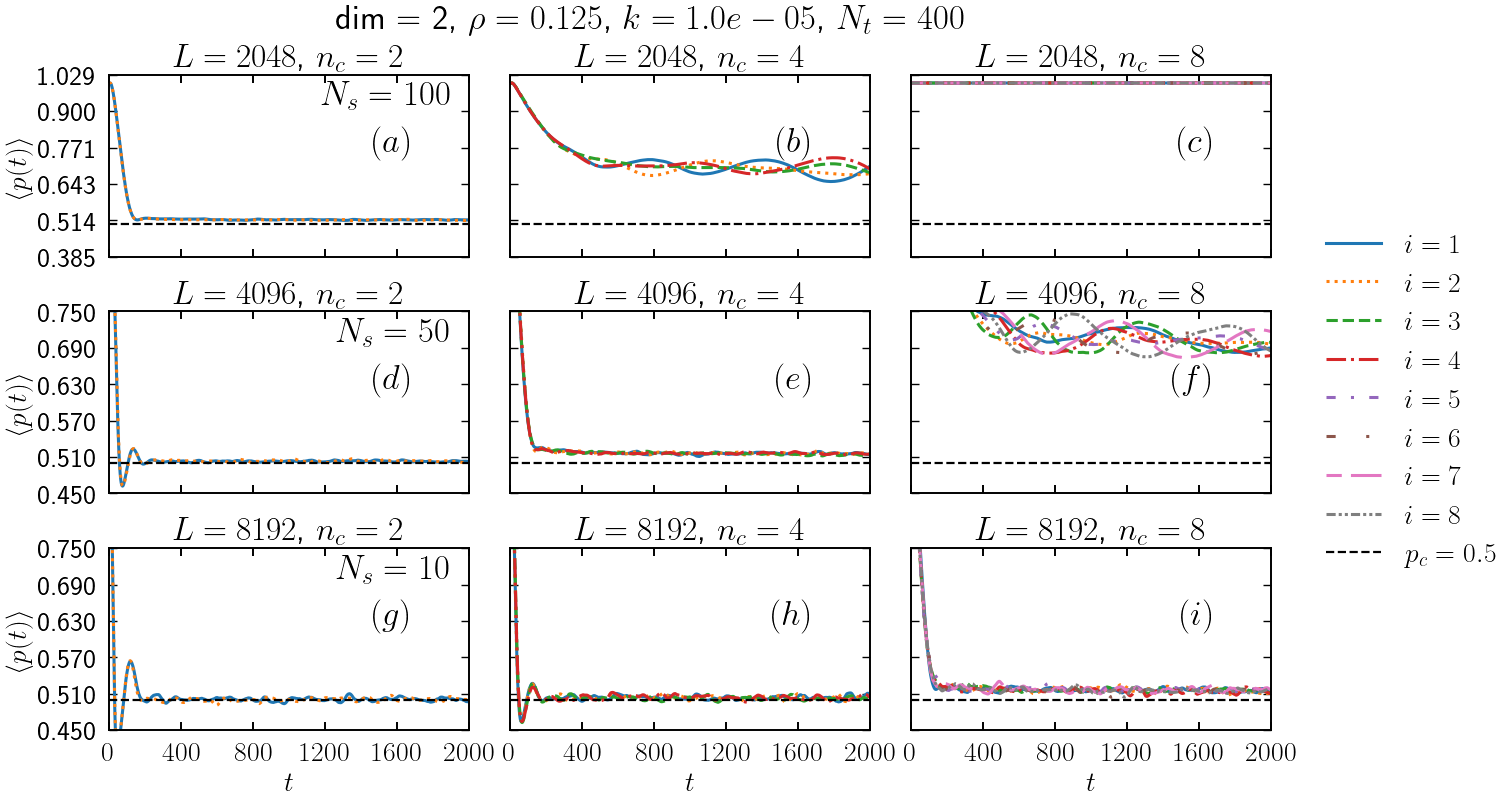

In [45]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from matplotlib.ticker import LinearLocator, AutoMinorLocator, FormatStrFormatter

def aplicar_ticks(ax, n_xticks=6, n_yticks=6, yfmt='%.3f'):
    # coloque isto DEPOIS de set_xlim/set_ylim
    ax.xaxis.set_major_locator(LinearLocator(n_xticks))
    ax.yaxis.set_major_locator(LinearLocator(n_yticks))
    
    ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)
    ax.yaxis.set_major_formatter(FormatStrFormatter(yfmt))  # opcional

L_list   = [2048, 4096, 8192]
DIM = 2
NT  = 400
k   = 1.0e-05
nc_list = [2, 4, 8]
p0 = 1.0
pc_ref = 0.50

ls = ['solid', 'dotted', 'dashed', 'dashdot', (0, (3, 5, 1, 5)),
      (0, (3, 10, 1, 10)), (5, (10, 3)), (0, (3, 1, 1, 1, 1, 1)),
      (0, (3, 10, 1, 10, 1, 10))]

fig, axes = plt.subplots(3, 3, figsize=(13, 8), sharex=True, sharey=False , constrained_layout=True)

labels_fig = ["$(a)$", "$(b)$", "$(c)$", 
              "$(d)$", "$(e)$", "$(f)$",
              "$(g)$", "$(h)$", "$(i)$"]
labels_Ns = [r"$N_s = 100$", "$N_s = 50$", "$N_s = 10$"]
legend_lines = {}  # guarda um Line2D por índice i

lw = 2.2

for i_row, L in enumerate(L_list):
    for j_col, nc_val in enumerate(nc_list):
        ax = axes[i_row, j_col]
        rho = 0.125
        filename = (
            f"../Data/bond_percolation/num_colors_{nc_val}/dim_{DIM}/"
            f"L_{L}/NT_constant/NT_{NT}/k_{k:.1e}/rho_{rho:.4e}/all_data_bundle.json"
        )

        try:
            bundle, df = read_all_data_bundle(filename, as_dataframe=True)
        except Exception:
            ax.text(0.5, 0.5, "arquivo não encontrado\nou erro ao ler",
                    ha='center', va='center', transform=ax.transAxes, fontsize=10)
            ax.set_title(fr"$L={L}$, $n_c={nc_val}$")
            continue

        if df.empty:
            ax.text(0.5, 0.5, "sem dados", ha='center', va='center',
                    transform=ax.transAxes, fontsize=10)
            ax.set_title(fr"$L={L}$, $n_c={nc_val}$")
            continue

        orders = np.sort(df['order'].unique())
        x_max = 0.0

        for idx_ord, ord_val in enumerate(orders, start=1):
            df_f = df[df['order'] == ord_val]
            if df_f.empty:
                continue

            line, = ax.plot(df_f['t'], df_f['pt'],
                            lw=lw,
                            ls=ls[idx_ord-1],  # <- corrige o off-by-one
                            label=fr'$i={idx_ord}$')

            # guarde o primeiro artista de cada i para a legenda global
            if idx_ord not in legend_lines:
                legend_lines[idx_ord] = line

            if len(df_f['t']) and np.nanmax(df_f['t']) > x_max:
                x_max = float(np.nanmax(df_f['t']))

        ax.set_title(fr"$L={L}$, $n_c={nc_val}$")
        if x_max > 0:
            ax.set_xlim(0, int(x_max))
        ax.axhline(y=pc_ref, ls='--', lw=1.6, color='k')

        if j_col == 0:
            ax.set_ylabel(r'$\langle p(t) \rangle$')
            ax.text(0.95, 0.80, labels_Ns[i_row],
                transform=ax.transAxes, ha='right', va='bottom', fontsize=25)
        
        if i_row == len(L_list) - 1:
            ax.set_xlabel(r'$t$')

        ax.set_xlim(0, 2000)

        aplicar_ticks(ax, n_xticks=6, n_yticks=6)
        if i_row != len(L_list) - 1:        # esconde nas linhas de cima
            ax.tick_params(axis='x', which='both', labelbottom=False)
        else:                                # mostra só na última linha
            ax.tick_params(axis='x', which='both', labelbottom=True)
        
        if j_col != 0:
            ax.tick_params(axis='y', which='both', labelleft=False)
        
        ax.set_ylim(0.385, 1.029)
        
        if i_row != 0:
            ax.set_ylim(0.45, 0.75)
        
        # Adiciona os labels nos cantos inferiores direitos
        ax.text(0.85, 0.53, labels_fig[i_row * len(nc_list) + j_col],
                transform=ax.transAxes, ha='right', va='bottom', fontsize=25)
         
# ===== legenda global usando os próprios artistas =====
fig.subplots_adjust(right=0.82)

# ordena por i e cria listas
handles = [legend_lines[i] for i in sorted(legend_lines.keys())]
labels = [fr'$i={i}$' for i in sorted(legend_lines.keys())]

# adiciona o handle do p_c
pc_handle = Line2D([0], [0], linestyle='--', linewidth=1.6, color='k')
handles.append(pc_handle)
labels.append(fr'$p_c={pc_ref}$')

fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5),
           frameon=False)
fig.suptitle(fr"dim = {DIM}, $\rho={rho}$, $k = {k:.1e}$, $N_t = {NT}$", fontsize=25, fontweight='bold')  # Adds a title to the entire figure

plt.savefig(results_folder + "/2D_TimeSeries_L_and_nc_multi_samples.pdf")
plt.show()